[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas
**Nombre** Regina Cabral

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
x = (x1, x2, x3, x4, x5,, x6)


**Funcion objetivo:**

min 4.5x1 + 9x2 + 2.5x3 + 3x4 + 15x5 + 3.5x6

**Restricciones:**
8 <= x1 + x2 + x3 + x4 + x5 + x6 <= 12
3.3x1 + 3.2x2 + 2x3 + 2.8x4 + 0x5 + 2.5x6 >= 25
90x1 + 440x2 + 80x3 + 40x4 + 0x5 + 150x6 >= 1000
0.3x1 + 2.7x2 + 4x3 + 8x4 + 200x5 + 1.5x6 >= 30
2.8x1 + 6.5x2 + 2x3 + 0.8x4 + 80x5 + 12x6 >= 20
x1 <= 6
x2 <= 3
x3 <= 5
x4 <= 2
x5 <= 0.5
x6 <= 4
x1,x2,x3,x4,x5,x6 >= 0

### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
Simplex

**Justificacion (2-3 oraciones):**
La función es lineal  y también todas las restricciones. Además las  restricciones son de desigualdad.

In [107]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [109]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    x = np.array(x, dtype=float)
    return float(costos_p1 @ x)


def verificar_p1(x, tol=1e-6):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
            'factible': bool
            'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
            'intake_total': float -- kg totales
    """
    x = np.array(x, dtype=float)

    nutrientes_totales = nutrientes_p1 @ x
    intake_total = float(np.sum(x))

    cumple_nutrientes = np.all(nutrientes_totales + tol >= req_min_p1)
    cumple_intake = (intake_total + tol >= intake_min_p1) and (intake_total - tol <= intake_max_p1)
    cumple_bounds = np.all(x + tol >= 0.0) and np.all(x - tol <= max_kg_p1)

    factible = bool(cumple_nutrientes and cumple_intake and cumple_bounds)

    return {
        "factible": factible,
        "nutrientes_totales": nutrientes_totales,
        "intake_total": intake_total,
    }



def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa los datos globales (costos_p1, nutrientes_p1, etc.)
    y el optimizador que elegiste en la seccion 1.2.

    Returns:
        x_opt: np.array (6,) -- kg optimos de cada ingrediente
        costo_opt: float -- costo minimo
    """
    n = len(costos_p1)

    A_ub = []
    b_ub = []
    for i in range(4):
        A_ub.append(-nutrientes_p1[i])
        b_ub.append(-req_min_p1[i])

    A_ub.append(np.ones(n))
    b_ub.append(intake_max_p1)

    A_ub.append(-np.ones(n))
    b_ub.append(-intake_min_p1)

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    bounds = [(0, max_kg_p1[i]) for i in range(n)]

    res = linprog(
        c=costos_p1,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs"
    )

    return res.x, res.fun

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


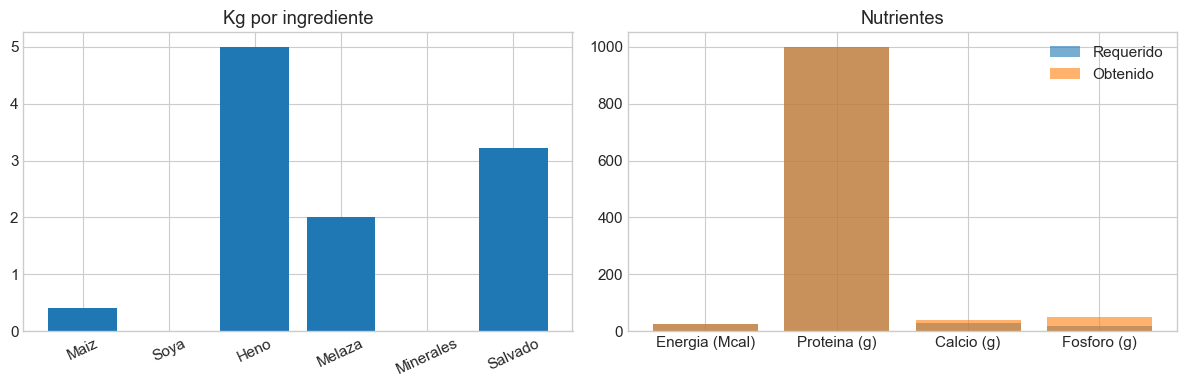

In [111]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos

    Args:
        x_opt: np.array (6,)
        costo_opt: float
    """
    nutrientes_totales = nutrientes_p1 @ x_opt

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Panel 1: kg por ingrediente
    axes[0].bar(nombres_p1, x_opt)
    axes[0].set_title("Kg por ingrediente")
    axes[0].tick_params(axis='x', rotation=25)

    # Panel 2: Nutrientes obtenidos vs requeridos
    axes[1].bar(nombres_nutrientes_p1, req_min_p1, alpha=0.6, label="Requerido")
    axes[1].bar(nombres_nutrientes_p1, nutrientes_totales, alpha=0.6, label="Obtenido")
    axes[1].set_title("Nutrientes")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

x = (x1, x2, x3, x4, x5)

**Funcion objetivo:**

min Sum(var(xiRi)) con Ri: rendimiento esperado por activo

**Restricciones:**
Sum(xiRi) >= 0.08
x1 + x2 + x3 + x4 + x5 = 1
x1,x2,x3,x4,x5>=0
x1,x2,x3,x4,x5<=0.4

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
KKT (SLSQP en python)

**Justificacion (2-3 oraciones):**
Es cuadrática con restricciones de desigualdad

In [116]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [118]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio.

    Args:
        w: np.array (5,) -- proporcion invertida en cada activo

    Returns:
        float -- varianza del portafolio
    """
    w = np.array(w, dtype=float)
    return float(w.T @ cov_p2 @ w)


def verificar_p2(w, tol = 1e-6):
    """Verifica si el portafolio cumple todas las restricciones.

    Args:
        w: np.array (5,) -- proporciones

    Returns:
        dict con:
            'factible': bool
            'rendimiento': float -- rendimiento esperado del portafolio
            'varianza': float
            'suma_pesos': float
    """
    w = np.array(w, dtype=float)

    suma = float(np.sum(w))
    rendimiento = float(w @ rendimientos_p2)
    varianza = float(w.T @ cov_p2 @ w)

    ok_suma = abs(suma - 1.0) <= 1e-4
    ok_min = np.min(w) >= -tol
    ok_max = np.max(w) <= 0.4 + tol
    ok_rend = rendimiento >= 0.08 - tol

    factible = bool(ok_suma and ok_min and ok_max and ok_rend)

    return {
        "factible": factible,
        "rendimiento": rendimiento,
        "varianza": varianza,
        "suma_pesos": suma,
        "min_peso": float(np.min(w)),
        "max_peso": float(np.max(w)),
    }
    return {
        "factible": factible,
        "rendimiento": rendimiento,
        "varianza": varianza,
        "suma_pesos": suma,
        "min_peso": float(np.min(w)),
        "max_peso": float(np.max(w)),
    }


def resolver_p2():
    """Resuelve el problema de portafolio.

    Returns:
        w_opt: np.array (5,) -- proporciones optimas
        varianza_opt: float -- varianza minima
    """
    n = len(rendimientos_p2)

    # Inicial: igual ponderado (si n=5 -> 0.2 cada uno)
    w0 = np.ones(n) / n

    # Bounds: 0 <= w_i <= 0.4
    bounds = [(0.0, 0.4) for _ in range(n)]

    # Restricciones en formato SciPy:
    # 1) sum(w) = 1  (igualdad)
    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        # 2) rendimiento >= 0.08 (inequidad: fun(w) >= 0)
        {"type": "ineq", "fun": lambda w: (w @ rendimientos_p2) - 0.08},
    ]

    res = minimize(
        objetivo_p2,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 2000, "ftol": 1e-12, "disp": False},
    )

    if not res.success:
        # A veces ayuda cambiar el punto inicial si cae en algo raro.
        # Intento extra: empezar metiendo 0.4 al mejor rendimiento y repartir lo demás.
        idx = int(np.argmax(rendimientos_p2))
        w1 = np.zeros(n)
        w1[idx] = 0.4
        resto = 0.6
        otros = [i for i in range(n) if i != idx]
        w1[otros] = resto / (n - 1)

        res2 = minimize(
            objetivo_p2,
            w1,
            method="SLSQP",
            bounds=bounds,
            constraints=cons,
            options={"maxiter": 3000, "ftol": 1e-12, "disp": False},
        )
        if res2.success:
            res = res2

    w_opt = np.array(res.x, dtype=float)
    var_opt = float(objetivo_p2(w_opt))

    return w_opt, var_opt

Solucion P2:
  Bonos gob.: 32.6%
  Acciones tech: 0.0%
  Bienes raices: 35.9%
  Materias primas: 17.9%
  Mercados emergentes: 13.6%
Rendimiento esperado: 8.00%
Varianza: 0.001471
Desv. estandar: 3.84%
Factible: True


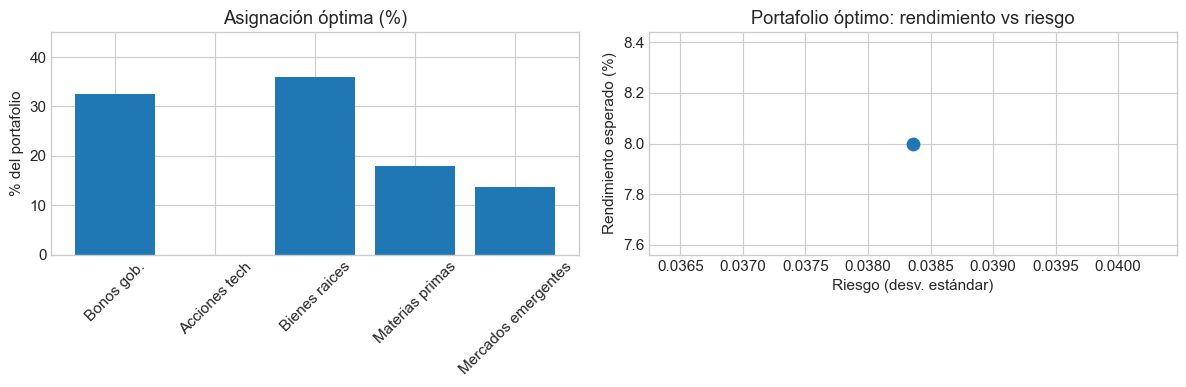

In [120]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo

    Args:
        w_opt: np.array (5,)
        varianza_opt: float
    """
    w_opt = np.array(w_opt, dtype=float)
    rend = float(w_opt @ rendimientos_p2)
    riesgo = float(np.sqrt(varianza_opt))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Panel 1
    axes[0].bar(activos_p2, w_opt * 100)
    axes[0].set_title("Asignación óptima (%)")
    axes[0].set_ylabel("% del portafolio")
    axes[0].set_ylim(0, max(45, (w_opt.max() * 100) + 5))
    axes[0].tick_params(axis="x", rotation=45)

    # Panel 2
    axes[1].scatter([riesgo], [rend * 100], s=80)
    axes[1].set_title("Portafolio óptimo: rendimiento vs riesgo")
    axes[1].set_xlabel("Riesgo (desv. estándar)")
    axes[1].set_ylabel("Rendimiento esperado (%)")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

x = (x1, x2, ..., x7) cada una es binaria

**Funcion objetivo:**

min 50x1 + 80x2 + 60x3 + 70x4 + 90x5 + 40x6 + 75x7

**Restricciones:**
Zona 1: x1 + x6 >= 1 (se construyé al menos 1, cubre zona)
Zona 2: x1 + x2 >= 1
Zona 3: x1 + x7 >= 1
Zona 4: x2 + x3 >= 1
Zona 5: x2 + x4 >= 1
Zona 6: x3 + x4 + x7 >= 1
Zona 7: x5 + x7 >= 1

### 3.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
MIP

**Justificacion (2-3 oraciones):**
Escogí MIP porque es un problema binario

In [125]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [127]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- 1 si se construye la torre, 0 si no

    Returns:
        float -- costo total
    """
    y = np.array(y, dtype=float)
    return float(np.dot(costos_torres_p3, y))


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- seleccion de torres

    Returns:
        dict con:
            'factible': bool -- True si todas las zonas estan cubiertas
            'zonas_cubiertas': list -- indices de zonas cubiertas
            'zonas_sin_cubrir': list -- indices de zonas sin cobertura
    """
    y = np.array(y, dtype=float)

    # cobertura_por_zona[j] = cuántas torres seleccionadas cubren la zona j
    cobertura_por_zona = (y @ cobertura_p3)  # (7,) @ (7,10) -> (10,)

    zonas_cubiertas = [j + 1 for j in range(n_zonas_p3) if cobertura_por_zona[j] >= 1]
    zonas_sin_cubrir = [j + 1 for j in range(n_zonas_p3) if cobertura_por_zona[j] < 1]

    factible = (len(zonas_sin_cubrir) == 0)

    return {
        "factible": factible,
        "zonas_cubiertas": zonas_cubiertas,
        "zonas_sin_cubrir": zonas_sin_cubrir
    }

def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres
        costo_opt: float -- costo minimo
    """
    n = n_torres_p3
    mejor_y = None
    mejor_costo = float("inf")

    for mask in range(1 << n):  # de 0 a 2^n - 1
        y = np.array([(mask >> i) & 1 for i in range(n)], dtype=float)

        info = verificar_p3(y)
        if info["factible"]:
            costo = objetivo_p3(y)
            if costo < mejor_costo:
                mejor_costo = costo
                mejor_y = y

    # Si por alguna razón no hay solución (no debería pasar), regresar algo razonable
    if mejor_y is None:
        mejor_y = np.zeros(n)
        mejor_costo = float("inf")

    return mejor_y, float(mejor_costo)

In [129]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura.

    Debe mostrar:
    - Que torres se seleccionaron (con costos)
    - Que zonas cubre cada torre seleccionada

    Args:
        y_opt: np.array (7,)
        costo_opt: float
    """
    y_opt = np.array(y_opt, dtype=float)
    info = verificar_p3(y_opt)

    print("=== Selección de torres (P3) ===")
    for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt)):
        if sel >= 0.5:
            zonas = [j + 1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
            print(f"- {nombre}: costo ${costos_torres_p3[i]:.0f}k, cubre zonas {zonas}")

    print(f"\nCosto total: ${costo_opt:.0f}k")
    print(f"Factible (cubre todas): {info['factible']}")
    if not info["factible"]:
        print(f"Zonas sin cubrir: {info['zonas_sin_cubrir']}")
    else:
        print("Todas las zonas están cubiertas ✅")


y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []
=== Selección de torres (P3) ===
- T2: costo $80k, cubre zonas [2, 3, 4, 5]
- T4: costo $70k, cubre zonas [5, 6, 7, 8]
- T6: costo $40k, cubre zonas [1, 9, 10]

Costo total: $190k
Factible (cubre todas): True
Todas las zonas están cubiertas ✅


---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

a, b, c, d

**Funcion objetivo:**

min y(t) - y(t*)

**Restricciones:**

0 <= a <= 5
0 <= b <=10
0 <= c <= 2pi
-3 <= d <=3

### 4.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
Simulated Annealing (L-BFGS en python)

**Justificacion (2-3 oraciones):**
NO es convexa y hay muchos mínimos locales

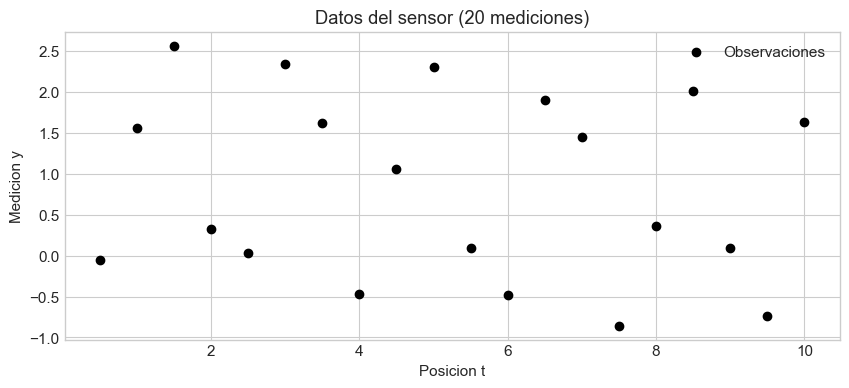

In [134]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [136]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones.

    Args:
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        float -- error total (escalar)
    """
    params = np.array(params, dtype=float)
    y_pred = modelo_sensor(t_obs_p4, params)
    resid = y_obs_p4 - y_pred
    return float(np.sum(resid**2))


def resolver_p4(n_intentos=60):
    """Resuelve el problema de calibracion.

    Returns:
        params_opt: np.array (4,) -- parametros optimos [a, b, c, d]
        error_opt: float -- error minimo encontrado
    """

    best_params = None
    best_err = float("inf")

    lows = np.array([b[0] for b in bounds_p4], dtype=float)
    highs = np.array([b[1] for b in bounds_p4], dtype=float)

    for _ in range(n_intentos):
        x0 = np.random.uniform(lows, highs)

        res = minimize(
            objetivo_p4,
            x0,
            method="L-BFGS-B",
            bounds=bounds_p4,
            options={"maxiter": 2000}
        )

        if res.fun < best_err:
            best_err = float(res.fun)
            best_params = np.array(res.x, dtype=float)

    return best_params, best_err

Solucion P4:
  a = 1.5090
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.088386


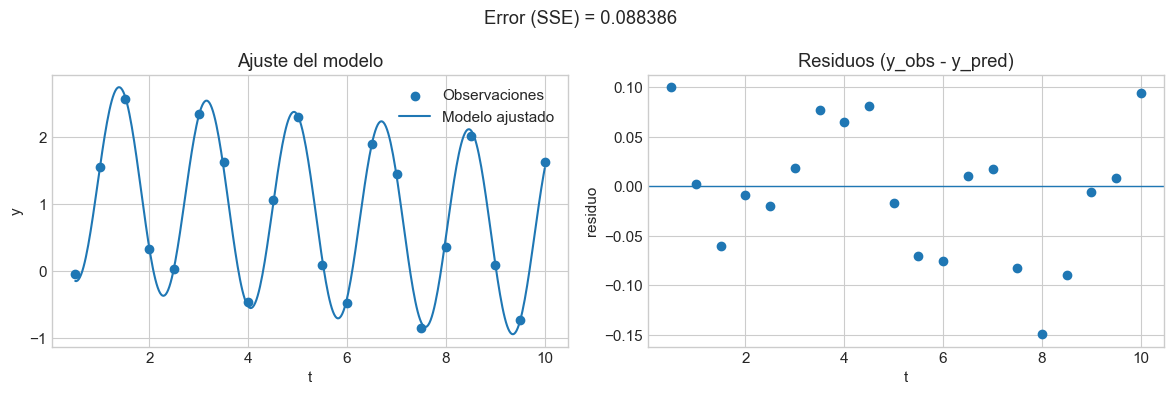

In [138]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos.

    Debe mostrar:
    - Datos observados (puntos)
    - Curva del modelo con parametros encontrados (linea)
    - Residuos (errores punto a punto)

    Args:
        params_opt: np.array (4,)
        error_opt: float
    """
    params_opt = np.array(params_opt, dtype=float)

    # curva suave del modelo para visualizar
    t_line = np.linspace(float(t_obs_p4.min()), float(t_obs_p4.max()), 400)
    y_line = modelo_sensor(t_line, params_opt)

    # predicción en puntos observados para residuos
    y_pred_obs = modelo_sensor(t_obs_p4, params_opt)
    resid = y_obs_p4 - y_pred_obs

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Panel 1: ajuste
    axes[0].scatter(t_obs_p4, y_obs_p4, label="Observaciones")
    axes[0].plot(t_line, y_line, label="Modelo ajustado")
    axes[0].set_title("Ajuste del modelo")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("y")
    axes[0].legend()
    axes[0].grid(True)

    # Panel 2: residuos
    axes[1].axhline(0, linewidth=1)
    axes[1].scatter(t_obs_p4, resid)
    axes[1].set_title("Residuos (y_obs - y_pred)")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("residuo")
    axes[1].grid(True)

    plt.suptitle(f"Error (SSE) = {error_opt:.6f}")
    plt.tight_layout()
    plt.show()

params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

x = (x1, x2, x3, x4) decisiones binarias
u = (u1, u2, u3, u4, u5, u6) decisiones continuas

**Funcion objetivo:**

min x1(800 + 4u1 + 8u2 + 5u3 + 9u4 + 7u5 + 6u6) + x2(700 + 7u1 + 3u2 + 6u3 + 8u4 + 4u5 + 9u6) + x3(1000 + 5u1 + 6u2 + 3u3 + 4u4 + 8u5 + 5u6) + x4(600 + 9u1 + 7u2 + 8u3 + 3u4 + 6u5 + 4u6)

**Restricciones:**
c11 + c21 + c31 + c41 = 120
c12 + c22 + c32 + c42 = 80
c13 + c23 + c33 + c43 = 200
c14 + c24 + c34 + c44 = 150
c15 + c25 + c35 + c45 = 100
c16 + c26 + c36 + c46 = 180
c11 + c12 + c13 + c14 + c15 + c16 <= 500
c21 + c22 + c23 + c24 + c25 + c26 <= 400
c31 + c32 + c33 + c34 + c35 + c36 <= 600
c41 + c42 + c43 + c44 + c45 + c46 <= 350

### 5.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
MIP

**Justificacion (2-3 oraciones):**
Son variables binarias

In [143]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [145]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio.

    Args:
        y: np.array (4,) -- 1 si el CD esta abierto, 0 si no
        X: np.array (4, 6) -- unidades enviadas de CD i a cliente j

    Returns:
        float -- costo total
    """
    costo_fijo = np.sum(costos_fijos_p5 * y)
    costo_envio = np.sum(costos_envio_p5 * X)
    return float(costo_fijo + costo_envio)


def verificar_p5(y, X):
    """Verifica si la solucion cumple todas las restricciones.

    Args:
        y: np.array (4,) -- apertura de CDs
        X: np.array (4, 6) -- envios

    Returns:
        dict con:
            'factible': bool
            'demanda_cumplida': np.array (6,) -- unidades recibidas por cada cliente
            'capacidad_usada': np.array (4,) -- capacidad usada por cada CD
    """
    demanda_recibida = X.sum(axis=0)

    capacidad_usada = X.sum(axis=1)

    ok_demanda = np.allclose(demanda_recibida, demandas_p5)
    ok_capacidad = np.all(capacidad_usada <= capacidades_p5 * y + 1e-6)

    return {
        "factible": bool(ok_demanda and ok_capacidad),
        "demanda_cumplida": demanda_recibida,
        "capacidad_usada": capacidad_usada
    }


def resolver_p5():
    """Resuelve el problema de red de distribucion.

    Returns:
        y_opt: np.array (4,) -- 1 si el CD se abre, 0 si no
        X_opt: np.array (4, 6) -- envios optimos
        costo_opt: float -- costo total minimo
    """
    best_cost = float("inf")
    best_y = None
    best_X = None

    # probar todas las combinaciones binarias de CDs abiertos
    for comb in itertools.product([0,1], repeat=n_cds_p5):
        y = np.array(comb)

        if np.sum(y) == 0:
            continue

        # matriz de envios
        X = np.zeros((n_cds_p5, n_clientes_p5))

        capacidad_restante = capacidades_p5 * y

        # asignar demanda al CD mas barato disponible
        for j in range(n_clientes_p5):
            demanda = demandas_p5[j]

            # ordenar CDs por costo creciente
            cds_ordenados = np.argsort(costos_envio_p5[:, j])

            for i in cds_ordenados:
                if y[i] == 0:
                    continue

                envio = min(demanda, capacidad_restante[i])
                X[i, j] += envio
                capacidad_restante[i] -= envio
                demanda -= envio

                if demanda <= 0:
                    break

        # verificar factibilidad
        info = verificar_p5(y, X)

        if info["factible"]:
            costo = objetivo_p5(y, X)
            if costo < best_cost:
                best_cost = costo
                best_y = y.copy()
                best_X = X.copy()

    return best_y, best_X, best_cost

[0 0 1 1]
[[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [120.  80. 200.   0.   0.  80.]
 [  0.   0.   0. 150. 100. 100.]]
5130.0


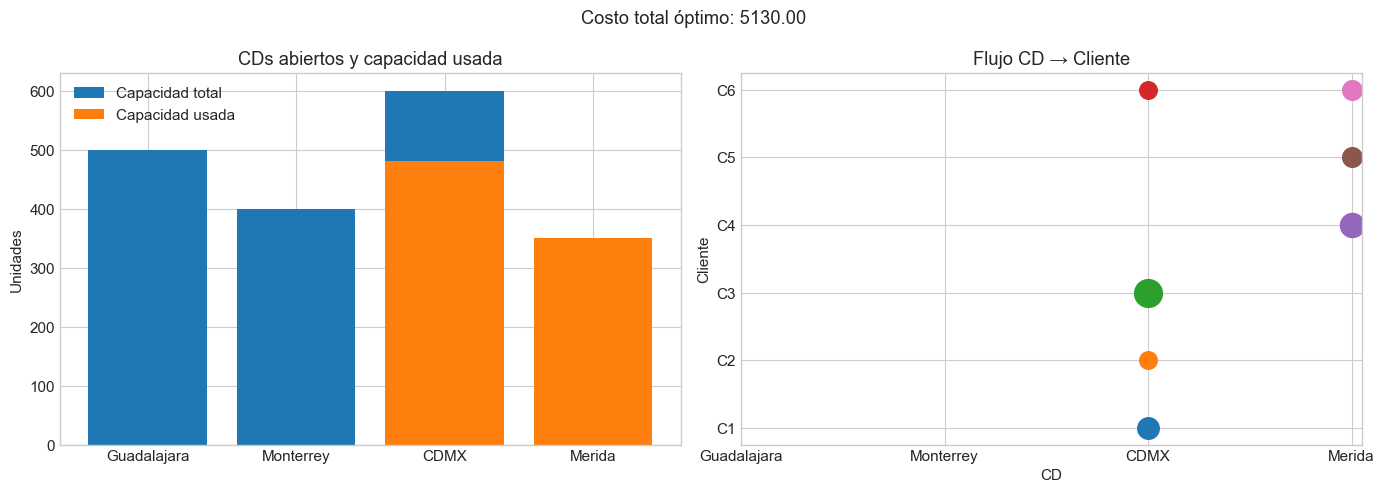

In [147]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion.

    Debe mostrar:
    - Que CDs estan abiertos (con capacidad usada vs disponible)
    - Flujo de envios: de cada CD a cada cliente

    Args:
        y_opt: np.array (4,)
        X_opt: np.array (4, 6)
        costo_opt: float
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ==========================
    # PANEL 1: CAPACIDADES
    # ==========================
    cap_usada = X_opt.sum(axis=1)

    indices = np.arange(n_cds_p5)

    axes[0].bar(indices, capacidades_p5, label="Capacidad total")
    axes[0].bar(indices, cap_usada, label="Capacidad usada")

    axes[0].set_xticks(indices)
    axes[0].set_xticklabels(ciudades_p5)
    axes[0].set_title("CDs abiertos y capacidad usada")
    axes[0].set_ylabel("Unidades")
    axes[0].legend()
    axes[0].grid(True)


    # ==========================
    # PANEL 2: FLUJOS
    # ==========================
    for i in range(n_cds_p5):
        for j in range(n_clientes_p5):
            if X_opt[i, j] > 0:
                axes[1].scatter(i, j, s=X_opt[i, j]*2)

    axes[1].set_xticks(range(n_cds_p5))
    axes[1].set_xticklabels(ciudades_p5)
    axes[1].set_yticks(range(n_clientes_p5))
    axes[1].set_yticklabels([f"C{j+1}" for j in range(n_clientes_p5)])

    axes[1].set_title("Flujo CD → Cliente")
    axes[1].set_xlabel("CD")
    axes[1].set_ylabel("Cliente")
    axes[1].grid(True)

    plt.suptitle(f"Costo total óptimo: {costo_opt:.2f}")
    plt.tight_layout()
    plt.show()

import itertools

y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
print(y_opt_p5)
print(X_opt_p5)
print(costo_opt_p5)

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)